In [1]:
import xarray as xr

ds = xr.open_mfdataset("/data/SO3/edavenport/tpose6/hycom_data/*.nc", combine="by_coords")

In [2]:
ds

<xarray.Dataset> Size: 349GB
Dimensions:     (time: 4084, depth: 28, lat: 251, lon: 1001)
Coordinates:
  * time        (time) datetime64[ns] 33kB 2012-08-01 ... 2013-12-31T21:00:00
  * depth       (depth) float64 224B 0.0 2.0 4.0 6.0 ... 300.0 350.0 400.0 500.0
  * lat         (lat) float64 2kB -10.0 -9.92 -9.84 -9.76 ... 9.84 9.92 10.0
  * lon         (lon) float64 8kB -180.0 -179.9 -179.8 ... -100.2 -100.1 -100.0
Data variables:
    water_u     (time, depth, lat, lon) float32 115GB dask.array<chunksize=(243, 28, 251, 1001), meta=np.ndarray>
    water_v     (time, depth, lat, lon) float32 115GB dask.array<chunksize=(243, 28, 251, 1001), meta=np.ndarray>
    surf_el     (time, lat, lon) float32 4GB dask.array<chunksize=(243, 251, 1001), meta=np.ndarray>
    water_temp  (time, depth, lat, lon) float32 115GB dask.array<chunksize=(243, 28, 251, 1001), meta=np.ndarray>
Attributes:
    classification_level:      UNCLASSIFIED
    distribution_statement:    Approved for public release. Distribution unli...
    downgrade_date:            not applicable
    classification_authority:  not applicable
    institution:               Naval Oceanographic Office
    source:                    HYCOM archive file
    history:                   archv2ncdf3z
    field_type:                instantaneous
    Conventions:               CF-1.6 NAVO_netcdf_v1.1

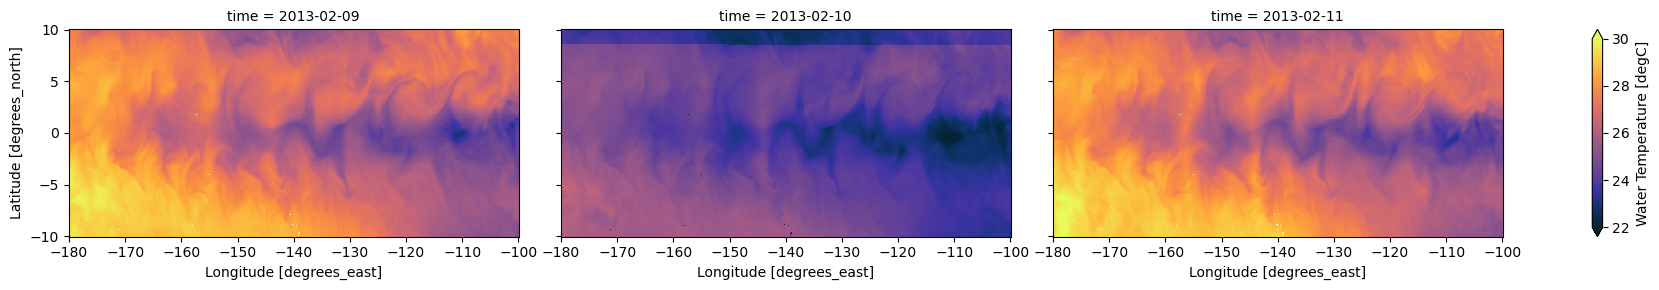

In [22]:
import cmocean.cm as cmo
ds = ds.sel(time=slice('2013-01-01', '2013-02-28'))
# take the daily mean 
ds = ds.resample(time='1D').mean()
# plot all three days in one figure
ds.sel(time=slice('2013-02-09','2013-02-11')).water_temp.isel(depth=0).plot(x='lon', y='lat',vmin=22, vmax=30, cmap=cmo.thermal, col='time',col_wrap=3,aspect=2)